# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model_ricard as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 1,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,                             # gamma parameter of the Boltzmann function (transfer function)
     'tau': 500,                                   # temperature parameter for the softmax 
     'T_crossover_ratio': 0,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,-1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'majority_ratio': 0.8,                       # output group: [np.ceil(par['majority_ratio']*par['L']):-1]
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'J_mutation_radius': 0.05,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.05,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.05,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.7,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'elitist_ratio':0.2,
     #'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 1000,                    # number of iterations of the algorithm
     'N_sol': 200}                       # number of solutions (individuals, networks) considered in the simulation

if par['reproduction_ratio'] + par['elitist_ratio'] > 1:
     print(f'Error: expected sum of reproduction ratio and elitist ratio to be at maximum 1, but instead got {par[
          'reproduction_ratio']} + {par['elitist_ratio']} = {par['reproduction_ratio']+par['elitist_ratio']}')

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean, loss_ev, mean_asp = m.evolution(par,verb=2,gen_verb=False,stat=True)

Iteration #0...
Mean loss: 1.0000389980331734
Best loss: 0.9999995365338116
Cumulative Best loss: 0.9999995365338116
Iteration #10...
Mean loss: 1.000124443969485
Best loss: 0.9999658799173041
Cumulative Best loss: 0.9999658799173041
Iteration #20...
Mean loss: 1.0000819945375887
Best loss: 0.9997549246029072
Cumulative Best loss: 0.9998201666780154
Iteration #30...
Mean loss: 0.9998146918867958
Best loss: 0.9971496687244124
Cumulative Best loss: 0.9985730159225435
Iteration #40...
Mean loss: 0.9973662380221165
Best loss: 0.9904240087652918
Cumulative Best loss: 0.9908348501041946
Iteration #50...
Mean loss: 0.9893430538197922
Best loss: 0.9758032222318624
Cumulative Best loss: 0.9781376918816269
Iteration #60...
Mean loss: 0.9812317565920803
Best loss: 0.9605990445796431
Cumulative Best loss: 0.9605990445796431
Iteration #70...
Mean loss: 0.9726525069928162
Best loss: 0.9380396374448645
Cumulative Best loss: 0.9433332924645044
Iteration #80...
Mean loss: 0.9548760816812123
Best loss: 

In [4]:
losses = []
for n,sol in enumerate(solutions[:10]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: -0.6415808618641883
Target distance:0.1284642785820181
Link cost:0.13882179451831658
Input: [-1, 1] -> Output: 0.3129222336698137
Target distance:0.47207585698527815
Link cost:0.13882179451831658
Input: [1, -1] -> Output: -0.6244356305602149
Target distance:2.638791117833563
Link cost:0.13882179451831658
Input: [1, 1] -> Output: -0.47462849701395987
Target distance:0.27601521614981084
Link cost:0.13882179451831658
loss:0.8788366173876674
Solution #1
Input: [-1, -1] -> Output: -0.7402364273432536
Target distance:0.06747711367939678
Link cost:0.146185830998733
Input: [-1, 1] -> Output: 0.33138736112078265
Target distance:0.4470428608690306
Link cost:0.146185830998733
Input: [1, -1] -> Output: 0.6575747153285761
Target distance:0.11725507558230566
Link cost:0.146185830998733
Input: [1, 1] -> Output: -0.19370428243325913
Target distance:0.6501127841664656
Link cost:0.146185830998733
loss:0.32047195857429966
Solution #2
Input: [-1, -1] -> Output: -0.81

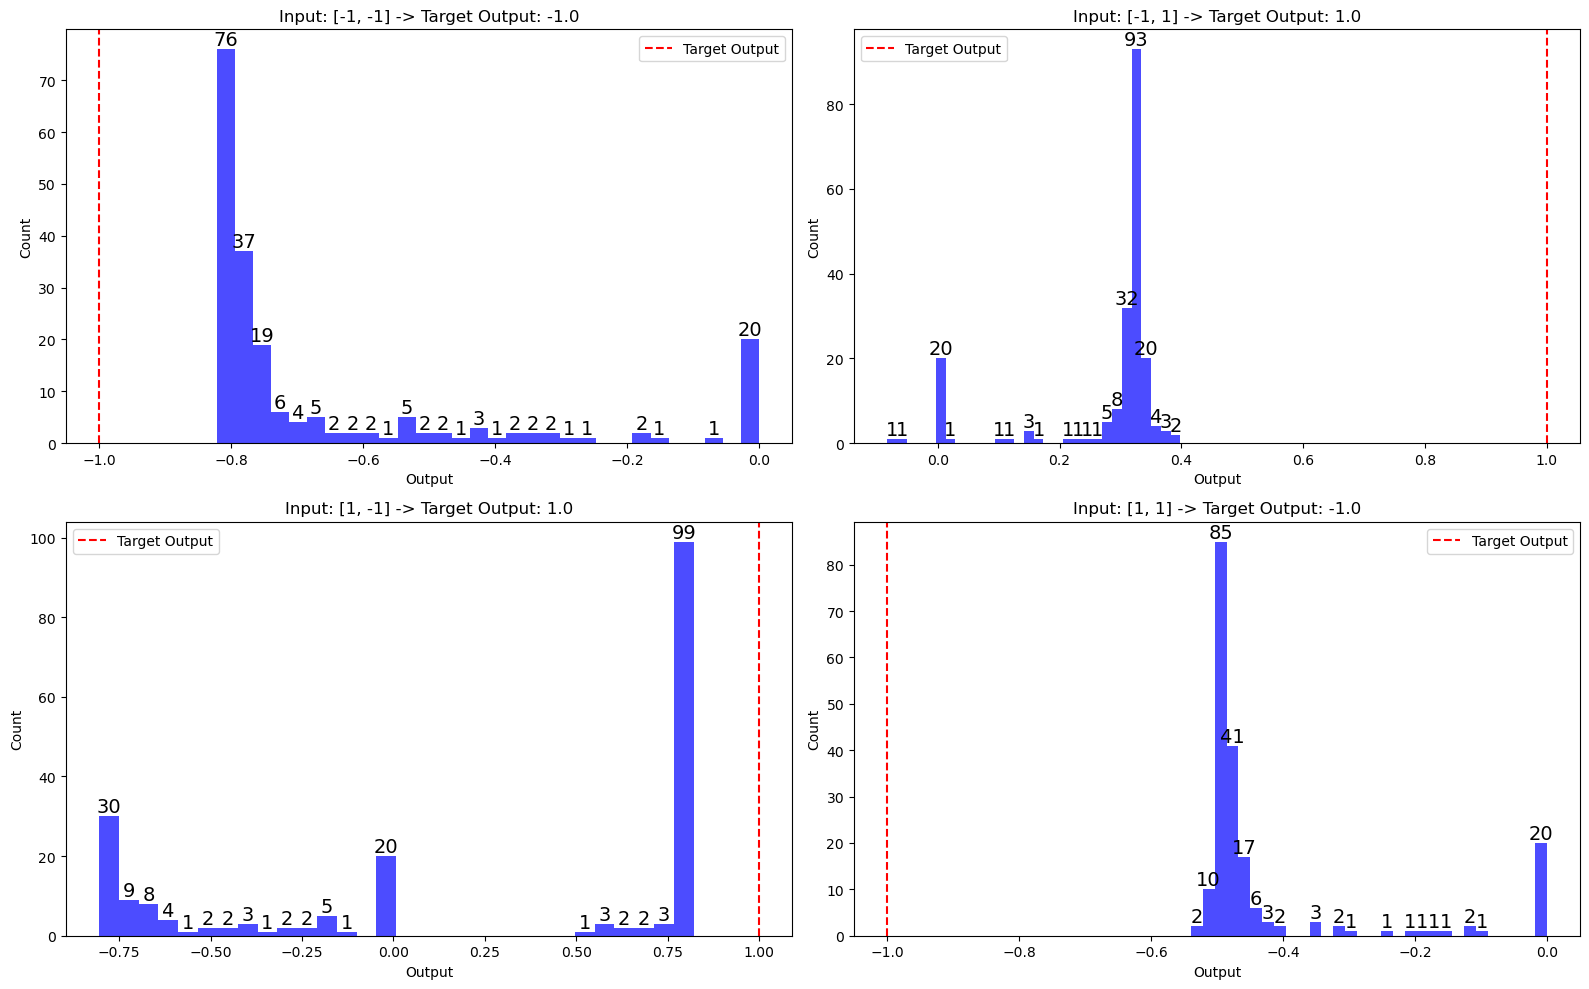

In [5]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

Links density:0.1875


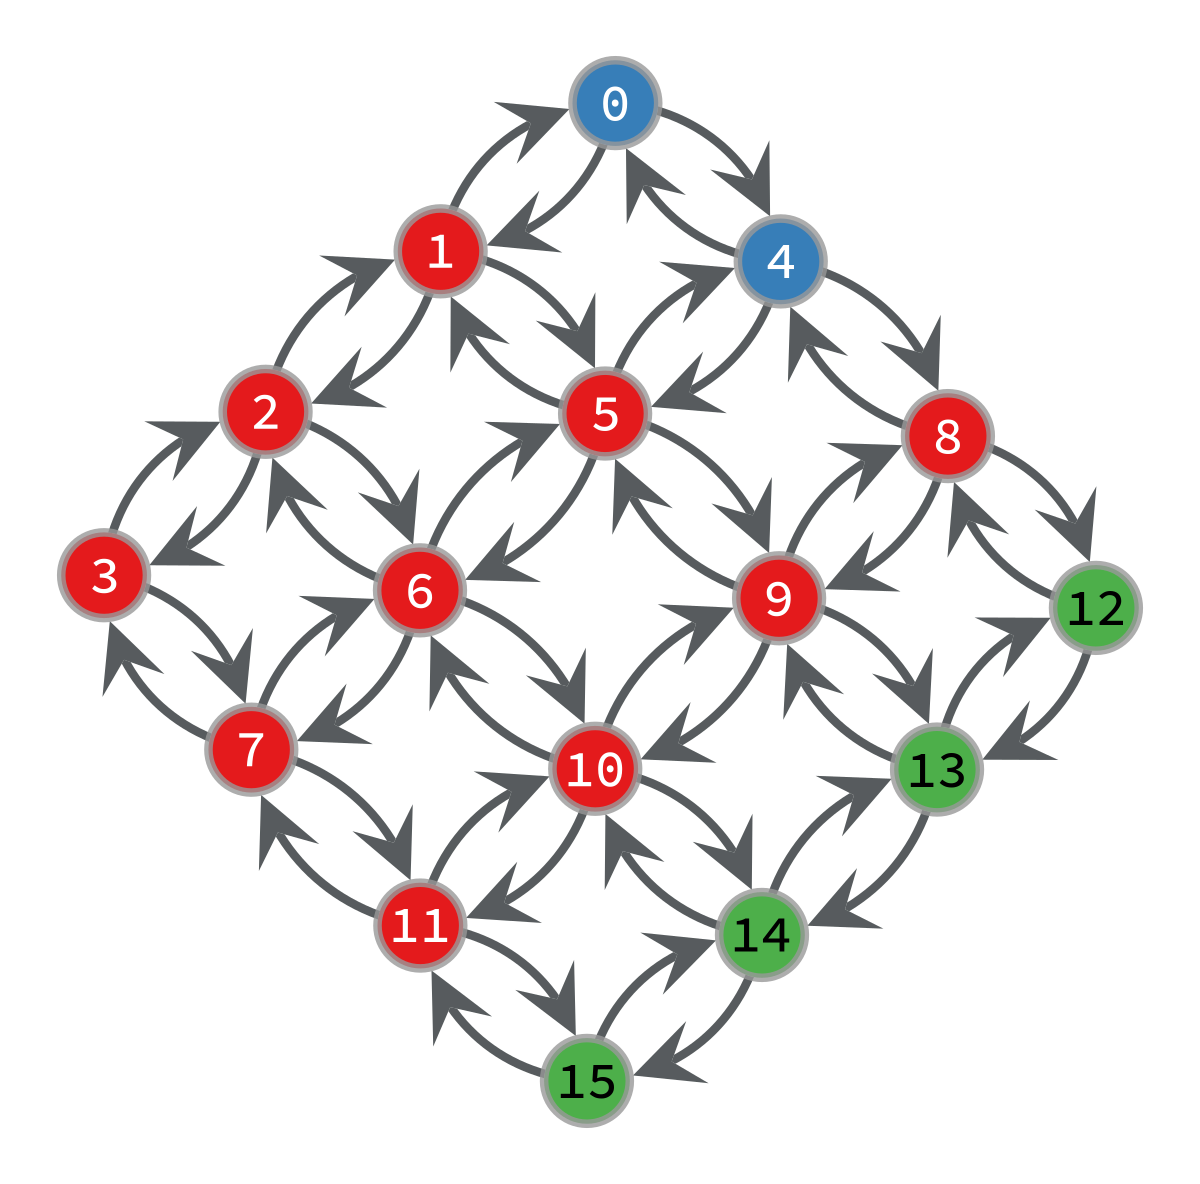

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f1dedbcccd0, at 0x7f1dedc1a580>

In [6]:
print(f'Links density:{np.sum(solutions[0].C)/solutions[0].C.shape[0]**2}')

graph = solutions[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1
highlight[graph.vertex(par['L'])] = 1
for i in range(int(par['majority_ratio']*(par['L']**2)),graph.num_vertices()):  # outputs
    highlight[graph.vertex(i)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [7]:
sol = sorted(solutions, key=lambda sol: sol.loss)
for i,input in enumerate(par['input_set']):
    output = m.ff(input,sol[0],par,verb=0)
    print(f'Input:{input} -> Output:{output} -- Expected:{par['target_set'][i]}')

Input:[-1, -1] -> Output:-0.8130632924669235 -- Expected:-1.0
Input:[-1, 1] -> Output:0.3215450930111527 -- Expected:1.0
Input:[1, -1] -> Output:0.8044134954861385 -- Expected:1.0
Input:[1, 1] -> Output:-0.49525665186571804 -- Expected:-1.0


Links density:0.19140625


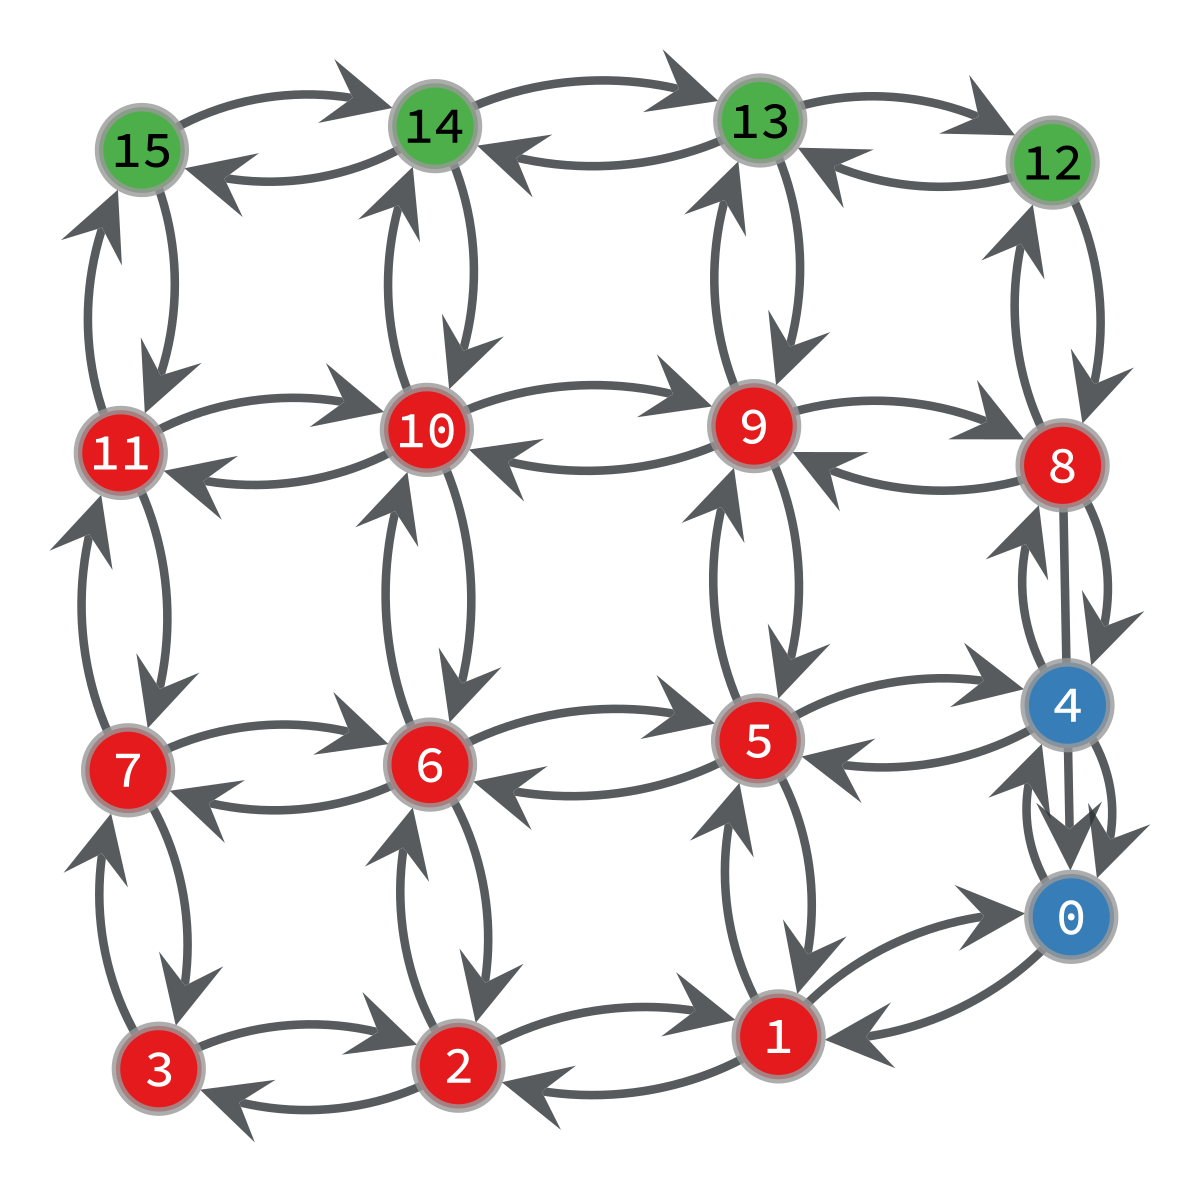

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f1dedbdc550, at 0x7f1dedc54050>

In [8]:
print(f'Links density:{np.sum(sol[0].C)/sol[0].C.shape[0]**2}')
graph = sol[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1
highlight[graph.vertex(par['L'])] = 1
for i in range(int(par['majority_ratio']*(par['L']**2)),graph.num_vertices()):  # outputs
    highlight[graph.vertex(i)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

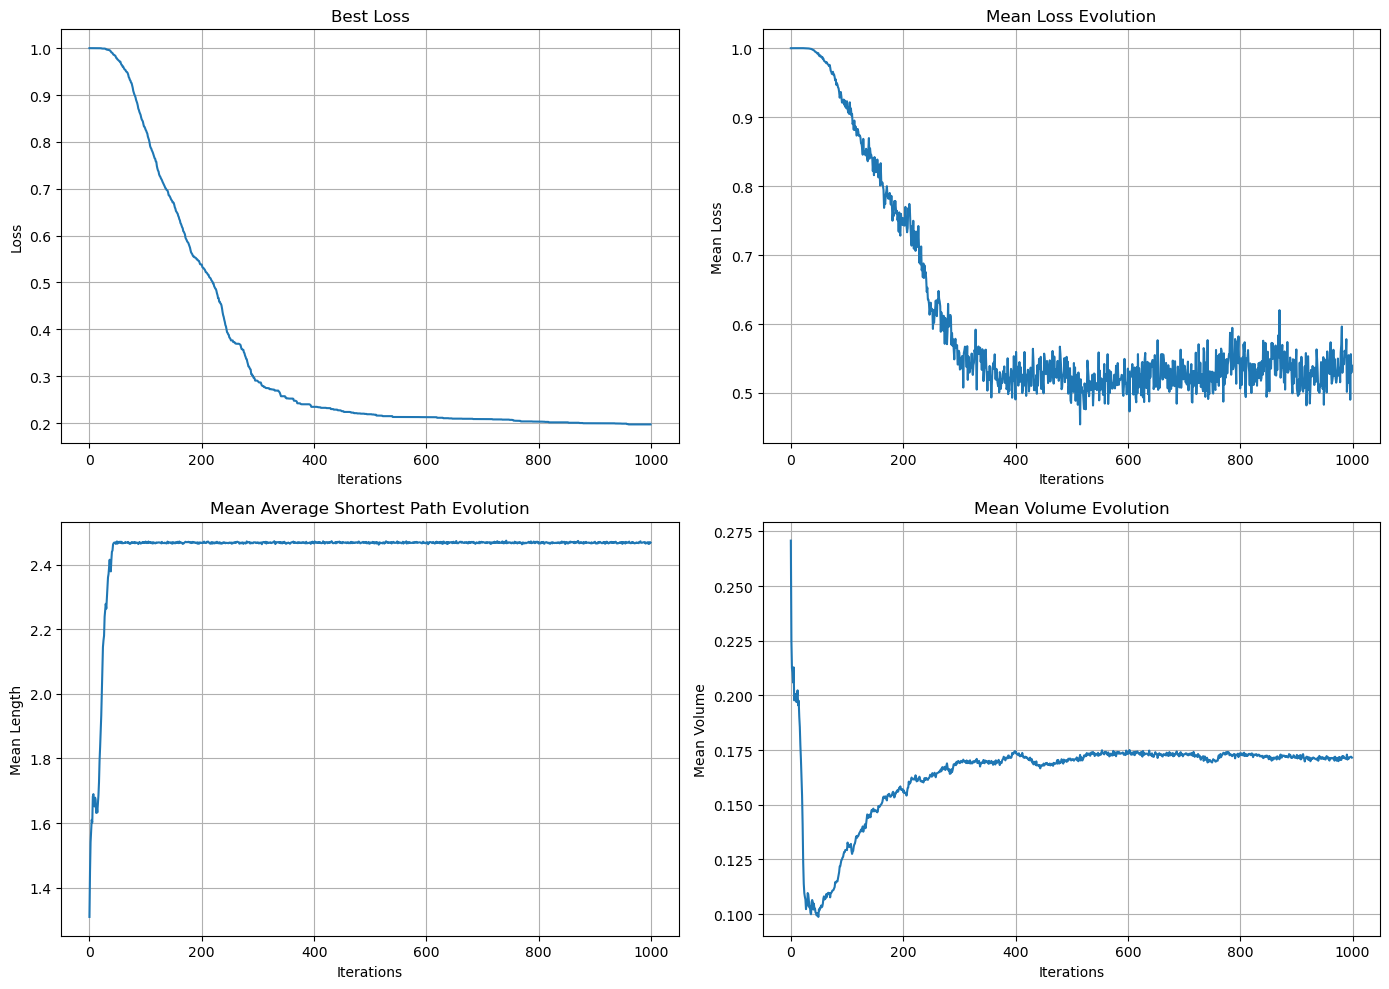

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Best Loss
best_loss = np.min(loss_ev, axis=0)
axs[0, 0].plot(best_loss)
axs[0, 0].set_title('Best Loss')
axs[0, 0].set_xlabel('Iterations')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

# Mean Loss Evolution
axs[0, 1].plot(np.arange(par['n_iter']), lmean)
axs[0, 1].set_title('Mean Loss Evolution')
axs[0, 1].set_xlabel('Iterations')
axs[0, 1].set_ylabel('Mean Loss')
#axs[0, 1].set_xscale('log')
axs[0, 1].grid(True)

# Mean Average Shortest Path Evolution
axs[1, 0].plot(mean_asp)
axs[1, 0].set_title('Mean Average Shortest Path Evolution')
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('Mean Length')
axs[1, 0].grid(True)

# Mean Volume Evolution
axs[1, 1].plot(volume_mean)
axs[1, 1].set_title('Mean Volume Evolution')
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('Mean Volume')
#axs[1, 1].set_xscale('log')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()
